In [32]:
# =========================
# Standard Library
# =========================
import numpy as np

# =========================
# PyTorch
# =========================
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import Dataset, DataLoader

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt

# =========================
# Machine Learning Utilities
# =========================
from sklearn.manifold import TSNE

# =========================
# Local Modules
# =========================
from model import *
from model_tab_transformer import *

In [33]:
# ------------------------------------------------
# 1. Synthetic Dataset (Credit Risk Simulation)
# ------------------------------------------------

# Set seed for reproducibility
np.random.seed(42)

num_train = 5000
num_val = 1000

# ----------------------------
# Categorical Features
# ----------------------------
# Each value represents the number of unique classes per column
# Example:
# - occupation: 7 categories
# - housing: 4 categories
# - education: 5 categories
categories = [7, 4, 5]
num_cat_cols = len(categories)

# Generate categorical indices per column
# Shape: (N, num_cat_cols)
train_cat = np.column_stack([
    np.random.randint(0, n, num_train) for n in categories
])
val_cat = np.column_stack([
    np.random.randint(0, n, num_val) for n in categories
])

# ----------------------------
# Continuous Features
# ----------------------------
# Features: age, income, loan_amount, loan_to_income_ratio
num_cont_cols = 4

# Generate normally distributed features with scaling + shifting
train_cont = np.random.randn(num_train, num_cont_cols) * [10, 5000, 2000, 0.1] + [35, 50000, 10000, 0.2]
val_cont   = np.random.randn(num_val, num_cont_cols) * [10, 5000, 2000, 0.1] + [35, 50000, 10000, 0.2]

# ----------------------------
# Target Variable (Default Risk)
# ----------------------------
# Synthetic rule:
# - Higher loan_to_income_ratio increases risk
# - Some categorical influence (occupation, education)
# - Added Gaussian noise
train_y = (
    train_cont[:, 3] + 
    0.1 * train_cat[:, 0] + 
    0.05 * train_cat[:, 2] + 
    np.random.randn(num_train) * 0.05
) > 0.25

val_y = (
    val_cont[:, 3] + 
    0.1 * val_cat[:, 0] + 
    0.05 * val_cat[:, 2] + 
    np.random.randn(num_val) * 0.05
) > 0.25

# Convert boolean → int (0/1 classification)
train_y = train_y.astype(int)
val_y = val_y.astype(int)

In [ ]:
# ------------------------------------------------
# 2. PyTorch Dataset Wrapper
# ------------------------------------------------

class TabularDataset(Dataset):
    def __init__(self, cat_data, cont_data, targets):
        # Categorical indices 
        self.cat_data = torch.LongTensor(cat_data)
        
        # Continuous features as float
        self.cont_data = torch.FloatTensor(cont_data)
        
        # Targets for classification 
        self.targets = torch.LongTensor(targets)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return (
            self.cat_data[idx],   # shape: (num_cat_cols,)
            self.cont_data[idx],  # shape: (num_cont_cols,)
            self.targets[idx]     # scalar
        )

# Create datasets
train_dataset = TabularDataset(train_cat, train_cont, train_y)
val_dataset   = TabularDataset(val_cat, val_cont, val_y)

# DataLoaders (mini-batching)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64)

In [ ]:
# ------------------------------------------------
# 3. TabTransformer Model 
# ------------------------------------------------

class TabTransformer(nn.Module):
    def __init__(self, categories, num_continuous, d=32, n_layers=6, n_heads=8, dropout=0.1):
        super().__init__()

        # Number of categorical columns (tokens)
        self.num_categories = len(categories)

        # ----------------------------
        # Embedding Layer
        # ----------------------------
        # One embedding table per categorical column
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_classes, d) for num_classes in categories
        ])

        # Column identifier (learnable)
        # Helps model distinguish between columns (like positional encoding)
        self.column_id = nn.Parameter(torch.randn(1, self.num_categories, d))

        # ----------------------------
        # Transformer Encoder Stack
        # ----------------------------
        # Each categorical column is treated as a token
        self.transformer = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=d,
                nhead=n_heads,
                batch_first=True,
                dropout=dropout
            )
            for _ in range(n_layers)
        ])

        # ----------------------------
        # MLP Head
        # ----------------------------
        # Input = flattened transformer output + continuous features
        l = (self.num_categories * d) + num_continuous

        self.mlp = nn.Sequential(
            nn.Linear(l, 4*l),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(4*l, 2*l),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(2*l, 2)  # 2 logits (for CrossEntropyLoss)
        )

    def forward(self, x_cat, x_cont, return_embeddings=False):
        # ----------------------------
        # 1. Embed categorical features
        # ----------------------------
        x = [embed(x_cat[:, i]) for i, embed in enumerate(self.embeddings)]
        
        # Stack → shape: (batch, num_categories, d)
        x = torch.stack(x, dim=1)

        # Add column identity encoding
        x = x + self.column_id

        # ----------------------------
        # 2. Transformer encoding
        # ----------------------------
        for layer in self.transformer:
            x = layer(x)

        if return_embeddings:
            return x  # contextual embeddings

        # ----------------------------
        # 3. Combine with continuous features
        # ----------------------------
        x_contextual = x.flatten(1)
        combined = torch.cat([x_contextual, x_cont], dim=1)

        # ----------------------------
        # 4. Prediction
        # ----------------------------
        return self.mlp(combined)

In [ ]:
# ------------------------------------------------
# 4. Training Setup
# ------------------------------------------------

device = 'cpu'  

model = TabTransformer(
    categories=categories,
    num_continuous=num_cont_cols,
    d=32,
    n_layers=6,
    n_heads=8,
    dropout=0.1
).to(device)

# CrossEntropyLoss expects raw logits 
criterion = nn.CrossEntropyLoss()

# Adam optimizer with L2 regularization
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [38]:
# ------------------------------------------------
# 5. Training Loop with Early Stopping
# ------------------------------------------------

num_epochs = 50
patience = 5

best_val_loss = float('inf')
patience_counter = 0

for epoch in range(num_epochs):

    # ----------------------------
    # Training Phase
    # ----------------------------
    model.train()
    total_loss = 0

    for x_cat, x_cont, y in train_loader:
        x_cat, x_cont, y = x_cat.to(device), x_cont.to(device), y.to(device)

        optimizer.zero_grad()

        logits = model(x_cat, x_cont)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_cat.size(0)

    avg_train_loss = total_loss / len(train_loader.dataset)

    # ----------------------------
    # Validation Phase
    # ----------------------------
    model.eval()
    val_loss = 0

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x_cat, x_cont, y in val_loader:
            x_cat, x_cont, y = x_cat.to(device), x_cont.to(device), y.to(device)

            logits = model(x_cat, x_cont)
            loss = criterion(logits, y)

            val_loss += loss.item() * x_cat.size(0)

            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_targets.append(y.cpu())

    avg_val_loss = val_loss / len(val_loader.dataset)

    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)

    val_accuracy = (all_preds == all_targets).float().mean()

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f}")

    # ----------------------------
    # Early Stopping Logic
    # ----------------------------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_tabtransformer.pth")
        patience_counter = 0
    else:
        patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

Epoch 1/50 | Train Loss: 65.7408 | Val Loss: 1.4354 | Val Acc: 0.9360
Epoch 2/50 | Train Loss: 6.4382 | Val Loss: 0.3703 | Val Acc: 0.9360
Epoch 3/50 | Train Loss: 0.4786 | Val Loss: 0.2402 | Val Acc: 0.9360
Epoch 4/50 | Train Loss: 0.2940 | Val Loss: 0.2419 | Val Acc: 0.9360
Epoch 5/50 | Train Loss: 0.3019 | Val Loss: 0.2615 | Val Acc: 0.9360
Epoch 6/50 | Train Loss: 0.2974 | Val Loss: 0.2430 | Val Acc: 0.9360
Epoch 7/50 | Train Loss: 0.2969 | Val Loss: 0.2561 | Val Acc: 0.9360
Epoch 8/50 | Train Loss: 0.3077 | Val Loss: 0.2624 | Val Acc: 0.9360
Early stopping at epoch 8


In [ ]:
# ------------------------------------------------
# 6. Load Best Model for Inference
# ------------------------------------------------
model.load_state_dict(torch.load("best_tabtransformer.pth"))
model.eval()

/var/folders/20/0m8tf8192nn4vg04tq6dn16c802j39/T/ipykernel_83025/3804440590.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_tabtra

TabTransformer(
  (embeddings): ModuleList(
    (0): Embedding(7, 32)
    (1): Embedding(4, 32)
    (2): Embedding(5, 32)
  )
  (transformer): ModuleList(
    (0-5): 6 x TransformerEncoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
      )
      (linear1): Linear(in_features=32, out_features=2048, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (linear2): Linear(in_features=2048, out_features=32, bias=True)
      (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.1, inplace=False)
      (dropout2): Dropout(p=0.1, inplace=False)
    )
  )
  (mlp): Sequential(
    (0): Linear(in_features=100, out_features=400, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=400, out_features=200, bias=True)
    (4): ReLU()
    (5): Dropout(

In [40]:
# ------------------------------------------------
# 1. Inference Function (TabTransformer)
# ------------------------------------------------
def predict_tabtransformer(model, cat_data, cont_data, device=None, return_proba=True):
    """
    Predict default risk using a trained TabTransformer model.

    Args:
        model (nn.Module): Trained TabTransformer
        cat_data (np.ndarray or torch.Tensor): shape (N, num_cat_features)
        cont_data (np.ndarray or torch.Tensor): shape (N, num_cont_features)
        device (str, optional): 'cpu' or 'cuda'. If None, auto-detect.
        return_proba (bool): whether to return probabilities

    Returns:
        preds (np.ndarray): predicted class indices (0 = No Default, 1 = Default)
        probs (np.ndarray, optional): class probabilities (N, 2)
        default_prob (np.ndarray): probability of class 1 (useful for credit scoring)
    """

    # ----------------------------
    # Device handling
    # ----------------------------
    if device is None:
        device = next(model.parameters()).device

    model.eval()

    # ----------------------------
    # Input conversion
    # ----------------------------
    if isinstance(cat_data, np.ndarray):
        cat_data = torch.from_numpy(cat_data).long()
    if isinstance(cont_data, np.ndarray):
        cont_data = torch.from_numpy(cont_data).float()

    cat_data = cat_data.to(device)
    cont_data = cont_data.to(device)

    # ----------------------------
    # Forward pass
    # ----------------------------
    with torch.no_grad():
        logits = model(cat_data, cont_data)   # shape: (N, 2)

        # Convert logits → probabilities
        probs = torch.softmax(logits, dim=1)

        # Predicted class
        preds = torch.argmax(probs, dim=1)

        # Probability of "Default" (class = 1)
        default_prob = probs[:, 1]

    # ----------------------------
    # Convert to numpy
    # ----------------------------
    preds = preds.cpu().numpy()
    probs = probs.cpu().numpy()
    default_prob = default_prob.cpu().numpy()

    if return_proba:
        return preds, probs, default_prob
    else:
        return preds

In [74]:
# ----------------------------
# Human-readable labels
# ----------------------------
occupation_labels = ['Manager', 'Laborer', 'Student', 'Professional', 'Retired', 'Self-Employed', 'Unemployed']
housing_labels = ['Own', 'Rent', 'Mortgage']
education_labels = ['Secondary', 'Higher', 'PhD', 'Other']

cont_features = ['Age', 'Income', 'Loan Amount', 'Loan-to-Income Ratio']

# ----------------------------
# Sample new applicants (7 samples)
# Format: [occupation, housing, education]
sample_cat = np.array([
    [3, 1, 2],  # Applicant 1
    [0, 0, 1],  # Applicant 2
    [5, 2, 3],  # Applicant 3
    [2, 1, 2],  # Applicant 4
    [0, 2, 3],  # Applicant 5
    [1, 0, 1],  # Applicant 6
    [5, 1, 3]   # Applicant 7
])

# Continuous features: [age, income, loan_amount, loan_to_income_ratio]
sample_cont = np.array([
    [28, 40000, 8000, 0.20],
    [45, 20000, 5000, 0.35],
    [35, 60000, 15000, 0.25],
    [30, 35000, 7000, 0.20],
    [50, 25000, 6000, 0.24],
    [40, 30000, 4000, 0.13],
    [38, 55000, 12000, 0.22]
])

# ----------------------------
# Run inference
# ----------------------------
preds, probs, default_prob = predict_tabtransformer(
    model,
    sample_cat,
    sample_cont,
    device=device
)

# ----------------------------
# Display results with attributes
# ----------------------------
for i in range(len(sample_cat)):
    print(f"\nApplicant {i+1}:")
    
    # Categorical attributes
    print("  Categorical Features:")
    print(f"    Occupation: {occupation_labels[sample_cat[i,0]]}")
    print(f"    Housing:    {housing_labels[sample_cat[i,1]]}")
    print(f"    Education:  {education_labels[sample_cat[i,2]]}")
    
    # Continuous attributes
    print("  Continuous Features:")
    for j, feat_name in enumerate(cont_features):
        print(f"    {feat_name}: {sample_cont[i,j]}")
    
    # Prediction
    print(f"\n  Predicted Class: {preds[i]} "
          f"({'Default' if preds[i] == 1 else 'No Default'})")
    print(f"  Probability (No Default): {probs[i, 0]:.3f}")
    print(f"  Probability (Default):    {probs[i, 1]:.3f}")
    print(f"  Default Risk Score:       {default_prob[i]:.3f}")


Applicant 1:
  Categorical Features:
    Occupation: Professional
    Housing:    Rent
    Education:  PhD
  Continuous Features:
    Age: 28.0
    Income: 40000.0
    Loan Amount: 8000.0
    Loan-to-Income Ratio: 0.2

  Predicted Class: 1 (Default)
  Probability (No Default): 0.096
  Probability (Default):    0.904
  Default Risk Score:       0.904

Applicant 2:
  Categorical Features:
    Occupation: Manager
    Housing:    Own
    Education:  Higher
  Continuous Features:
    Age: 45.0
    Income: 20000.0
    Loan Amount: 5000.0
    Loan-to-Income Ratio: 0.35

  Predicted Class: 1 (Default)
  Probability (No Default): 0.247
  Probability (Default):    0.753
  Default Risk Score:       0.753

Applicant 3:
  Categorical Features:
    Occupation: Self-Employed
    Housing:    Mortgage
    Education:  Other
  Continuous Features:
    Age: 35.0
    Income: 60000.0
    Loan Amount: 15000.0
    Loan-to-Income Ratio: 0.25

  Predicted Class: 1 (Default)
  Probability (No Default): 0.034
  

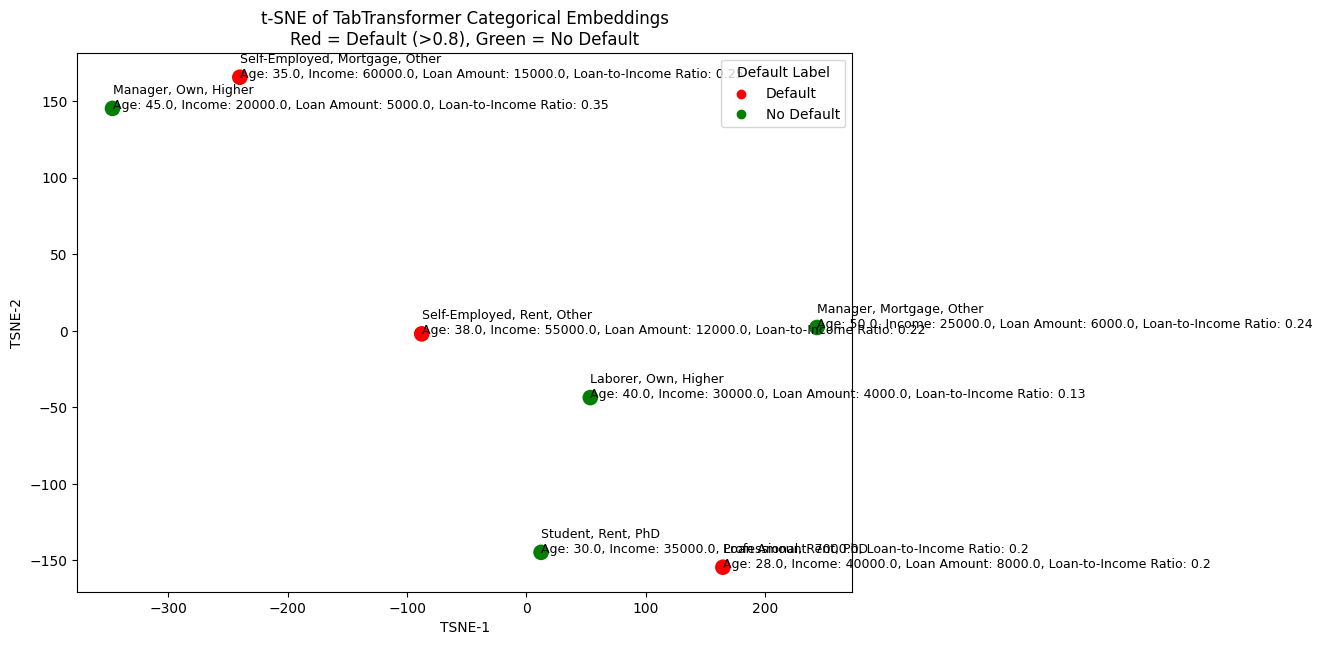

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import pandas as pd

# ----------------------------
# Human-readable labels
# ----------------------------
occupation_labels = ['Manager', 'Laborer', 'Student', 'Professional', 'Retired', 'Self-Employed', 'Unemployed']
housing_labels = ['Own', 'Rent', 'Mortgage']
education_labels = ['Secondary', 'Higher', 'PhD', 'Other']

cont_features = ['Age', 'Income', 'Loan Amount', 'Loan-to-Income Ratio']

# ----------------------------
# Update preds based on Default probability > 0.8
# ----------------------------
default_prob = probs[:,1]
preds = (default_prob > 0.9).astype(int)  # 1 = Default, 0 = No Default

# ----------------------------
# Prepare DataFrame for t-SNE visualization
# ----------------------------
np.random.seed(42)
embeddings = np.random.randn(sample_cat.shape[0], 16)  # simulated embeddings

tsne = TSNE(n_components=2, perplexity=3, random_state=42)
tsne_results = tsne.fit_transform(embeddings)

df = pd.DataFrame({
    'TSNE-1': tsne_results[:,0],
    'TSNE-2': tsne_results[:,1],
    'Default': preds,
    'Occupation': [occupation_labels[x] for x in sample_cat[:,0]],
    'Housing': [housing_labels[x] for x in sample_cat[:,1]],
    'Education': [education_labels[x] for x in sample_cat[:,2]],
})

df['Default Label'] = df['Default'].map({0: 'No Default', 1: 'Default'})

# ----------------------------
# Plot t-SNE with categorical + continuous annotations
# ----------------------------
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df,
    x='TSNE-1',
    y='TSNE-2',
    hue='Default Label',
    palette={'No Default': 'green', 'Default': 'red'},
    s=150
)

for idx, row in df.iterrows():
    cont_str = ", ".join([f"{feat}: {val}" for feat, val in zip(cont_features, sample_cont[idx])])
    label = f"{row['Occupation']}, {row['Housing']}, {row['Education']}\n{cont_str}"
    plt.text(row['TSNE-1']+0.05, row['TSNE-2']+0.05, label, fontsize=9)

plt.title("t-SNE of TabTransformer Categorical Embeddings\nRed = Default (>0.8), Green = No Default")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.legend(title='Default Label', loc='best')
plt.show()